 # **Implementasi Fuzzy System: Perbandingan Metode Mamdani dan Sugeno pada Pengaplikasian Dataset Body Fat**

## **BAB I**
## **PENDAHULUAN**

### **1.1 Latar Belakang**

Dalam beberapa tahun terakhir, kesadaran masyarakat akan pentingnya menjaga kesehatan tubuh terus mengalami peningkatan. Salah satu parameter utama yang sering digunakan untuk menilai kondisi kesehatan adalah persentase lemak tubuh. Parameter ini memberikan gambaran mengenai proporsi lemak dalam tubuh seseorang dibandingkan dengan total berat badannya. Oleh karena itu, pengukuran persentase lemak tubuh yang akurat menjadi hal yang sangat dibutuhkan saat ini.

Proses pengolahan data lemak tubuh biasanya melibatkan berbagai faktor, seperti lingkar perut dan lebar dada. Faktor-faktor tersebut memiliki hubungan yang . Faktor-faktor tersebut memiliki hubungan yang kompleks dan tidak linear, sehingga sulit dimodelkan secara langsung menggunakan metode perhitungan sederhana atau tradisional. Dalam kondisi ini, metode konvensional terkadang tidak cukup fleksibel untuk menangani tingkat kompleksitas tersebut.

Metode fuzzy dengan pendekatan Mamdani dan Sugeno menjadi dua metode yang umum digunakan dalam pengolahan data ini. Pendekatan Mamdani umumnya lebih cocok untuk pengambilan keputusan yang memerlukan range data yang sangat akurat, sementara metode Sugeno lebih sesuai untuk sistem yang membutuhkan hasil berupa fungsi matematis guna keperluan proses lanjutan. Dengan membandingkan kedua metode tersebut, diharapkan dapat ditemukan solusi terbaik untuk menghitung persentase lemak tubuh, baik dari segi akurasi maupun efisiensi.

### **1.2 Rumusan Masalah**
  Adapun rumusan masalah yang ingin diselesaikan pada studi kasus ini adalah sebagai berikut.
  1. Bagaimana cara mengembangkan sistem fuzzy manual menggunakan metode Mamdani untuk memprediksi tingkat Body Fat?
  2. Bagaimana cara mengembangkan sistem fuzzy manual menggunakan metode Sugeno untuk memprediksi tingkat Body Fat?
  3. Bagaimana kinerja kedua metode tersebut jika dibandingkan dalam hal akurasi prediksi dan efisiensi?


### **1.3 Batasan Masalah**
  Studi kasus ini memiliki beberapa batasan untuk memastikan ruang lingkupnya tetap terfokus dan dapat diselesaikan dengan data yang tersedia. Berikut adalah batasan masalah untuk studi kasus ini.
  1.  Studi ini hanya menggunakan parameter yang tersedia dalam dataset Body Fat, dalam hal ini menggunakan kolom Chest dan Abdomen untuk memprediksi BodyFat.
  2. Studi ini hanya menggunakan logika fuzzy dengan metode Mamdani dan Sugeno, tanpa melibatkan metode prediksi lainnya seperti regresi linier atau machine learning.
  3. Semua perhitungan fuzzy dilakukan secara manual menggunakan formula matematika tanpa menggunakan library seperti Scikit-Fuzzy atau library otomatis lainnya.

### **1.4 Tujuan**
  Beberapa tujuan yang ingin dicapai pada studi kasus ini adalah sebagai berikut.
  1. Mengembangkan sistem fuzzy berbasis Mamdani dan Sugeno untuk memperkirakan tingkat persentase lemak tubuh berdasarkan dataset yang tersedia.
  2. Mengevaluasi keakuratan model fuzzy dalam memproses data dan memberikan hasil yang relevan.
  3. Membandingkan kinerja metode Mamdani dan Sugeno dalam pengolahan dataset, baik dari segi akurasi hasil maupun efisiensi waktu proses.

## **BAB II**
## **PEMAPARAN DATA**

### 2.1 Sumber data

Sumber Data: https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset

### 2.2 Paparan dan Statistik Data

#### Informasi Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('bodyfat.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


#### Deskripsi Data

In [ ]:
df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


#### Korelasi Antar Data

In [ ]:
 df.corr()['BodyFat'].sort_values(ascending=False)

,BodyFat
BodyFat,1.000000
Abdomen,0.813432
Chest,0.702620
Hip,0.625201
Weight,0.612414
Thigh,0.559608
Knee,0.508665
Biceps,0.493271
Neck,0.490592
Forearm,0.361387


### 2.3 Pre-processing Data

Data tidak memiliki null values dan datatype juga sudah memiliki format yang sesuai sehingga tidak diperlukan pre-processing data karena kondisi data sudah bersih

## **BAB III**
## **METODE DAN EKSPERIMEN**

### **3.1 Penjelasan Metode yang Digunakan**

Pada studi kasus ini, digunakan metode Mamdani dan Sugeno untuk memprediksi kolom Body Fat. Kolom features yang digunakan untuk memprediksi kolom Body Fat yaitu kolom Chest dan Abdomen. Penggunaan kolom ini karena kolom-kolom tersebut memiliki nilai korelasi yang cukup tinggi dengan kolom Body Fat.

## **BAB IV**
## **HASIL DAN ANALISIS**

### 4.1 Jumlah Nilai Linguistik untuk Setiap Variabel

Dalam studi kasus ini, kolom feeatures dan target masing-masing memiliki 3 nilai linguistik, yaitu \
Chest: [Small, Medium, Large] \
Abdomen: [Small, Medium, Large]

### 4.2 Fungsi Keanggotaan

#### Batas Nilai Linguistik

**CHEST** \
Rentang ukuran Chest yang ditentukan adalah jika Chest < 94 termasuk dalam kategori **Small** dan jika Chest > 97 sudah tidak termasuk kategori **Small**. Kemudian, untuk ukuran diantara 97 dan 102 termasuk kategori **Medium** dengan fuzzyness dari 94 sampai 106. Untuk kategori **Large**, Chest > 106 dengan fuzzyness mulai dari 102. \

**ABDOMEN** \
Rentang ukuran Abdomen yang ditentukan adalah jika Abdomen < 84.5 termasuk dalam kategori **Small** dan mulai dari ukuran 87.7 sudah tidak termasuk dalam kategori **Small**. Kemudian, untuk ukuran diantara 87.7 hingga 95 termasuk dalam kategori **Medium**, dengan fuzzyness dari 84.5 sampai 99.3. Dan untuk ukuran > 99.3 masuk dalam kategori **Large**, dengan fuzzyness mulai dari 95. \

#### Fungsi Keanggotaan Chest

In [ ]:
def chest_small(chest):
  if chest < 94:
    return 1
  elif chest >= 94 and chest <= 97:
    return (97 - chest) / (97 - 94)
  else:
    return 0

def chest_medium(chest):
  if chest >= 94 and chest <= 97:
    return (chest - 94) / (97 - 94)
  elif chest > 97 and chest < 102:
    return 1
  elif chest >= 102 and chest < 106:
    return (106 - chest) / (106 - 102)
  else:
    return 0

def chest_large(chest):
  if chest >= 102 and chest < 106:
    return (chest - 102) / (106 - 102)
  elif chest > 106:
    return 1
  else:
    return 0

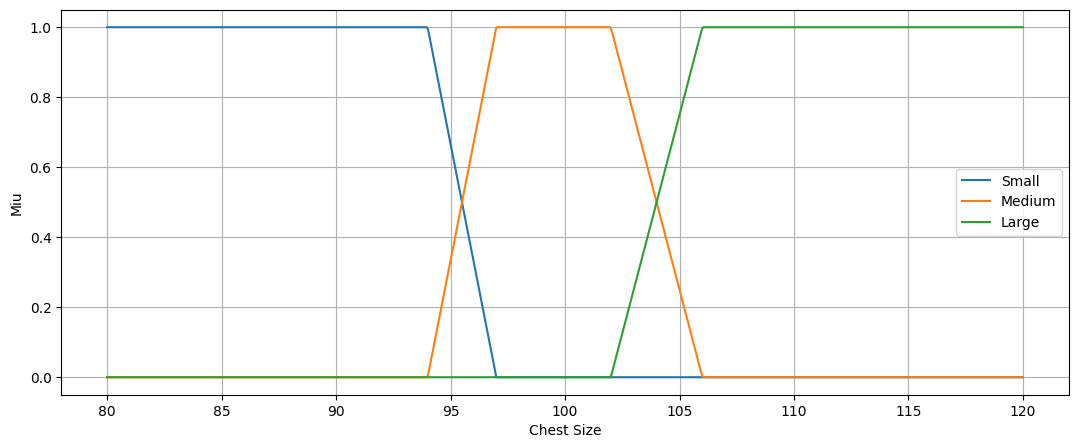

In [ ]:
chest_area = np.linspace(80, 120, 700)

anggota_chest_small = [chest_small(chest) for chest in chest_area]
anggota_chest_medium = [chest_medium(chest) for chest in chest_area]
anggota_chest_large = [chest_large(chest) for chest in chest_area]

plt.figure(figsize=(13, 5))
plt.plot(chest_area, anggota_chest_small, label='Small')
plt.plot(chest_area, anggota_chest_medium, label='Medium')
plt.plot(chest_area, anggota_chest_large, label='Large')
plt.xticks(np.arange(80, 121, 5))
plt.grid(True)
plt.xlabel('Chest Size')
plt.ylabel('Miu')
plt.legend()
plt.grid(True)
plt.show()

#### Fungsi Keanggotaan Abdomen

In [ ]:
def abdomen_small(abdomen):
  if abdomen <= 84.5:
    return 1
  elif abdomen > 84.5 and abdomen <= 87.7:
    return (87.7 - abdomen) / (87.7 - 84.5)
  else:
    return 0

def abdomen_medium(abdomen):
  if abdomen > 84.5 and abdomen <= 87.7:
    return (abdomen - 84.5) / (87.7 - 84.5)
  elif abdomen > 87.7 and abdomen <= 95:
    return 1
  elif abdomen > 95 and abdomen < 99.3:
    return (99.3 - abdomen) / (99.3 - 95)
  else:
    return 0

def abdomen_large(abdomen):
  if abdomen > 95 and abdomen < 99.3:
    return (abdomen - 95) / (99.3 - 95)
  elif abdomen > 99.3:
    return 1
  else:
    return 0

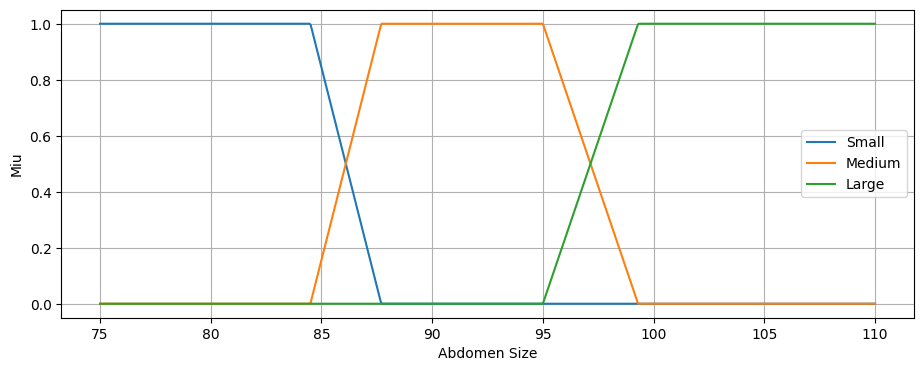

In [ ]:
abdomen_area = np.linspace(75, 110, 700)

anggota_abdomen_small = [abdomen_small(abdomen) for abdomen in abdomen_area]
anggota_abdomen_medium = [abdomen_medium(abdomen) for abdomen in abdomen_area]
anggota_abdomen_large = [abdomen_large(abdomen) for abdomen in abdomen_area]

plt.figure(figsize=(11, 4))
plt.plot(abdomen_area, anggota_abdomen_small, label='Small')
plt.plot(abdomen_area, anggota_abdomen_medium, label='Medium')
plt.plot(abdomen_area, anggota_abdomen_large, label='Large')
plt.xticks(np.arange(75, 111, 5))
plt.grid(True)
plt.xlabel('Abdomen Size')
plt.ylabel('Miu')
plt.legend()
plt.grid(True)
plt.show()

### 4.3 Fuzzy Rules Table

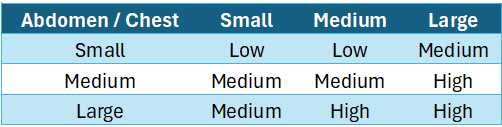

### 4.4 Inference

In [ ]:
def inference(abdomen, chest):
  # Hitung keanggotaan sebelum masuk fuzzy rules
  abdomen_smal = abdomen_small(abdomen)
  abdomen_med = abdomen_medium(abdomen)
  abdomen_lar = abdomen_large(abdomen)
  chest_smal = chest_small(chest)
  chest_med = chest_medium(chest)
  chest_lar = chest_large(chest)

  # Fuzzy Rules
  rules = {
      "Low" : [
          min(abdomen_smal, chest_smal),
          min(abdomen_smal, chest_med)
      ],
      "Medium" :[
          min(abdomen_smal, chest_lar),
          min(abdomen_med, chest_smal),
          min(abdomen_med, chest_med),
          min(abdomen_lar, chest_smal)
      ],
      "High" :[
          min(abdomen_med, chest_lar),
          min(abdomen_lar, chest_med),
          min(abdomen_lar, chest_lar)
      ]
  }

  # Agregasi output
  low = max(rules["Low"])
  medium = max(rules["Medium"])
  high = max(rules["High"])

  return {"Low": low, "Medium": medium, "High": high}

### 4.5 Defuzzyfikasi Mamdani

In [ ]:
def low_fat(BodyFat):
  if BodyFat <= 12.475:
    return 1
  elif BodyFat > 12.475 and BodyFat <= 15.8375:
    return (15.8375 - BodyFat) / (15.8375 - 12.475)
  else:
    return 0

def medium_fat(BodyFat):
  if BodyFat > 12.475 and BodyFat <= 15.8375:
    return (BodyFat - 12.475) / (15.8375 - 12.475)
  elif BodyFat > 15.8375 and BodyFat <= 22.25:
    return 1
  elif BodyFat > 22.25 and BodyFat <= 25.3:
    return (25.3 - BodyFat) / (25.3 - 22.25)
  else:
    return 0

def high_fat(BodyFat):
  if BodyFat > 22.25 and BodyFat <= 25.3:
    return (BodyFat - 22.25) / (25.3 - 22.25)
  elif BodyFat > 25.3:
    return 1
  else:
    return 0

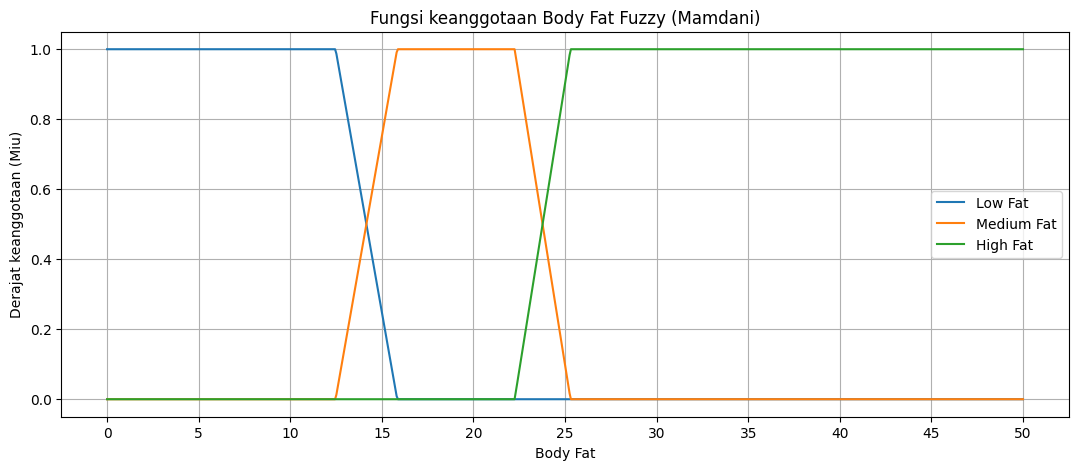

In [ ]:
x = np.linspace(0, 50, 700)

kat_lowFat = [low_fat(value) for value in x]
kat_mediumFat = [medium_fat(value) for value in x]
kat_highFat = [high_fat(value) for value in x]

plt.figure(figsize=(13, 5))
plt.plot(x, kat_lowFat, label='Low Fat')
plt.plot(x, kat_mediumFat, label='Medium Fat')
plt.plot(x, kat_highFat, label='High Fat')
plt.xticks(np.arange(0, 51, 5))
plt.grid(True)
plt.title("Fungsi keanggotaan Body Fat Fuzzy (Mamdani)")
plt.xlabel('Body Fat')
plt.ylabel('Derajat keanggotaan (Miu)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Defuzzyfikasi
def defuzzyfikasi(output):
  x = np.linspace(0, 50, 1000)
  aggregated = np.zeros_like(x)

  #Agregasi keanggotaan
  for i in range(len(x)):
    aggregated[i] = max(
        min(output["Low"], low_fat(x[i])),
        min(output["Medium"], medium_fat(x[i])),
        min(output["High"], high_fat(x[i]))
    )

  #Hitung centroid
  numerator = np.sum(x * aggregated)
  denominator = np.sum(aggregated)

  centroid = numerator / denominator

  return centroid

In [ ]:
# cek hasil
Chest = 100
Abdomen = 90
print(f"Chest : {Chest}")
print(f"Abdomen : {Abdomen}")

result = inference(Abdomen, Chest)
print(f"Hasil inference: {result}")
output = max(result, key=result.get)
print(f"Max inference: {output}")

hasil = defuzzyfikasi(result)

print(f"Hasil defuzzyfikasi: {hasil:.2f}")


Chest : 100
Abdomen : 90
Hasil inference: {'Low': 0, 'Medium': 1, 'High': 0}
Max inference: Medium
Hasil defuzzyfikasi: 18.96


In [ ]:
def kategoriFat(BodyFat):
    low = low_fat(BodyFat)
    medium = medium_fat(BodyFat)
    high = high_fat(BodyFat)

    if low >= medium and low >= high:
        return "Low"
    elif medium >= low and medium >= high:
        return "Medium"
    else:
        return "High"

def Klasifikasi_Fat(row):
    output = inference(row['Abdomen'], row['Chest'])

    output_category = max(output, key=output.get)
    crisp_output = defuzzyfikasi(output)
    return crisp_output

def cat_fat(row):
    output = inference(row['Abdomen'], row['Chest'])

    output_category = max(output, key=output.get)
    return output_category


df["Kat_Fat_Actual"] = df["BodyFat"].apply(kategoriFat)
df["Model Mamdani"] = df.apply(Klasifikasi_Fat, axis=1)
df["Kat_Fat_Mamdani"] = df.apply(cat_fat, axis=1)

df.tail(10)

<ipython-input-159-fa31f1b9727b>:18: RuntimeWarning: invalid value encountered in scalar divide
  centroid = numerator / denominator


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Kat_Fat_Actual,Model Mamdani,Kat_Fat_Mamdani
242,1.0304,30.4,66,234.25,72.00,41.4,119.7,109.0,109.1,63.7,42.4,24.6,35.6,30.7,19.5,High,36.885239,High
243,1.0256,32.6,67,227.75,72.75,41.3,115.8,113.4,109.8,65.6,46.0,25.4,35.3,29.8,19.5,High,36.885239,High
244,1.0334,29.0,67,199.50,68.50,40.7,118.3,106.1,101.6,58.2,38.8,24.1,32.1,29.3,18.5,High,36.885239,High
245,1.0641,15.2,68,155.50,69.25,36.3,97.4,84.3,94.4,54.3,37.5,22.6,29.2,27.3,18.5,Medium,7.098855,Low
246,1.0308,30.2,69,215.50,70.50,40.8,113.7,107.6,110.0,63.3,44.0,22.6,37.5,32.6,18.8,High,36.885239,High
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5,Low,7.098855,Low
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1,High,36.885239,High
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0,High,36.885239,High
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8,High,36.885239,High
251,1.0271,31.9,74,207.50,70.00,40.8,112.4,108.5,107.1,59.3,42.2,24.6,33.7,30.0,20.9,High,36.885239,High


### 4.6 Defuzzyfikasi Sugeno

In [ ]:
def lowFat_sugeno(data):
    if (data == 12):
        return 1
    else:
        return 0
def mediumFat_sugeno(data):
    if (data == 19):
        return 1
    else:
        return 0
def highFat_sugeno(data):
    if (data == 25):
        return 1
    else:
        return 0

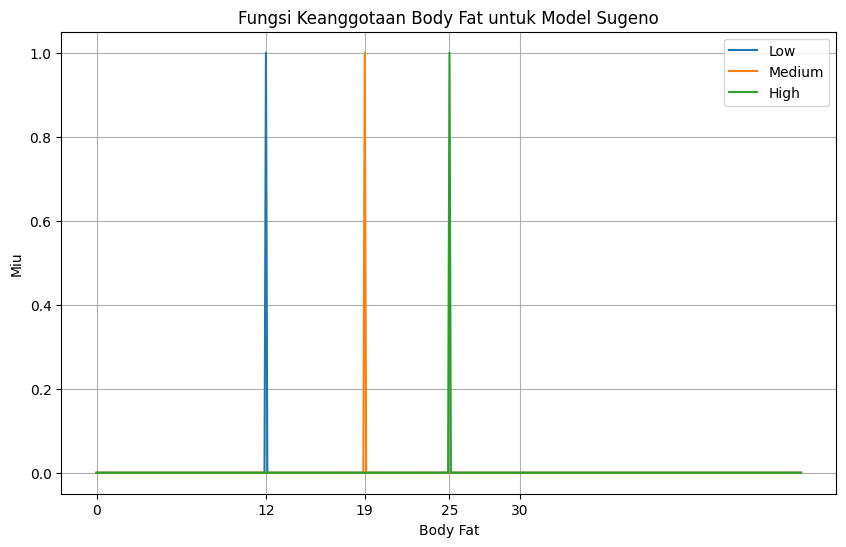

In [ ]:
bodyFat_range = np.arange(0,50,0.1)
low = [lowFat_sugeno(data) for data in bodyFat_range]
medium = [mediumFat_sugeno(data) for data in bodyFat_range]
high = [highFat_sugeno(data) for data in bodyFat_range]

plt.figure(figsize=(10, 6))
plt.plot(bodyFat_range, low, label='Low')
plt.plot(bodyFat_range, medium, label='Medium')
plt.plot(bodyFat_range, high, label='High')
plt.title('Fungsi Keanggotaan Body Fat untuk Model Sugeno')
plt.xlabel('Body Fat')
plt.xticks([0,12,19,25,30])
plt.ylabel('Miu')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def weighted_average(fuzzy_sets):
    total = fuzzy_sets['Low'] + fuzzy_sets['Medium'] + fuzzy_sets['High']
    if total == 0:  # Tangani kasus nol
        return 0
    return (fuzzy_sets['Low'] * 12 +
            fuzzy_sets['Medium'] * 19 +
            fuzzy_sets['High'] * 25) / total

def prediksi_dengan_model_sugeno(Abdomen, Chest):
  fuzzy_sets = inference(Abdomen, Chest)
  return weighted_average(fuzzy_sets)

In [ ]:
def klasifikasi_bodyFat_sugeno(row):
    # Hitung fuzzy output berdasarkan 'Abdomen' dan 'Chest'
    fuzzy_sets = inference(row['Abdomen'], row['Chest'])

    # Kategori Body Fat berdasarkan keanggotaan maksimum
    output_kategori = max(fuzzy_sets, key=fuzzy_sets.get)

    # Hitung weight average berdasarkan hasil Sugeno
    ratarata_output = prediksi_dengan_model_sugeno(row['Abdomen'], row['Chest'])

    return ratarata_output

def cat_fat_sugeno(row):
    low = low_fat(row['Model Sugeno'])
    medium = medium_fat(row['Model Sugeno'])
    high = high_fat(row['Model Sugeno'])
    if low >= medium and low >= high:
        return "Low"
    elif medium >= low and medium >= high:
        return "Medium"
    else:
        return "High"

df['Model Sugeno'] = df.apply(klasifikasi_bodyFat_sugeno, axis=1)
df["Kat_Fat_Sugeno"] = df.apply(cat_fat_sugeno, axis=1)
df.tail(20)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,Kat_Fat_Actual,Model Mamdani,Kat_Fat_Mamdani,Model Sugeno,Kat_Fat_Sugeno
232,1.0636,15.4,58,175.50,71.50,38.0,100.2,88.1,97.8,57.1,38.9,23.6,30.9,29.6,18.0,Medium,18.956960,Medium,19.000000,Medium
233,1.0384,26.7,58,161.75,67.25,35.1,94.9,94.9,100.2,56.8,35.9,21.0,27.8,26.1,17.6,High,18.938357,Medium,19.000000,Medium
234,1.0403,25.8,60,157.75,67.50,40.4,97.2,93.3,94.0,54.3,35.7,21.0,31.3,28.7,18.3,High,18.956960,Medium,19.000000,Medium
235,1.0563,18.6,62,168.75,67.50,38.3,104.7,95.6,93.7,54.4,37.1,22.7,30.3,26.3,18.3,Medium,33.850278,High,23.050000,Medium
236,1.0424,24.8,62,191.50,72.25,40.6,104.0,98.2,101.1,59.3,40.3,23.0,32.6,28.5,19.0,High,33.597241,High,22.969231,Medium
237,1.0372,27.3,63,219.15,69.50,40.2,117.6,113.8,111.8,63.4,41.1,22.3,35.1,29.6,18.5,High,36.885239,High,25.000000,High
238,1.0705,12.4,64,155.25,69.50,37.9,95.8,82.8,94.5,61.2,39.1,22.3,29.8,28.9,18.3,Low,7.413331,Low,12.000000,Low
239,1.0316,29.9,65,189.75,65.75,40.8,106.4,100.5,100.5,59.2,38.1,24.0,35.9,30.5,19.1,High,36.885239,High,25.000000,High
240,1.0599,17.0,65,127.50,65.75,34.7,93.0,79.7,87.6,50.7,33.4,20.1,28.5,24.8,16.5,Medium,7.098855,Low,12.000000,Low
241,1.0207,35.0,65,224.50,68.25,38.8,119.6,118.0,114.3,61.3,42.1,23.4,34.9,30.1,19.4,High,36.885239,High,25.000000,High


### 4.7 Akurasi Kategori Mamdani dan Sugeno

In [ ]:
pembilang_Mamdani = (df['Kat_Fat_Actual'] == df['Kat_Fat_Mamdani']).sum()

penyebut_Mamdani = len(df)

akurasi_Mamdani = pembilang_Mamdani / penyebut_Mamdani
print(f"Akurasi Mamdani: {akurasi_Mamdani:.2%}")

Akurasi Mamdani: 64.29%


In [ ]:
pembilang_Sugeno = (df['Kat_Fat_Actual'] == df['Kat_Fat_Sugeno']).sum()

penyebut_Sugeno = len(df)

akurasi_Sugeno = pembilang_Sugeno / penyebut_Sugeno
print(f"Akurasi Sugeno: {akurasi_Sugeno:.2%}")

Akurasi Sugeno: 66.67%


### 4.8 Akurasi menggunakan SMAPE
Menghitung akurasi berdasarkan perbedaan nilai actual dengan hasil defuzzyfikasi

In [ ]:
def smape(actual, predicted):
    """Menghitung sMAPE antara nilai aktual dan prediksi."""
    numerator = abs(actual - predicted)
    denominator = (abs(actual) + abs(predicted)) / 2
    smape_values = 100 * (numerator / denominator)
    smape_values[denominator == 0] = 0  # Tangani kasus denominator nol
    return smape_values.mean()

# Hitung sMAPE untuk masing-masing model
smape_mamdani = smape(df['BodyFat'], df['Model Mamdani'])
smape_sugeno = smape(df['BodyFat'], df['Model Sugeno'])

# Tampilkan hasil
print(f"sMAPE Model Mamdani: {smape_mamdani:.2f}%")
print(f"sMAPE Model Sugeno: {smape_sugeno:.2f}%")

sMAPE Model Mamdani: 36.44%
sMAPE Model Sugeno: 28.32%


## BAB 5

### Kesimpulan

Berdasarkan akurasi, metode Sugeno memiliki performa yang lebih tinggi dibandingkan dengan metode Mamdani. Akurasi kategori Sugeno mencapai 66.67%, lebih tinggi dibandingkan Mamdani yang mencapai 64.29%. Selain itu, berdasarkan nilai sMAPE, Sugeno memiliki tingkat kesalahan prediksi yang lebih rendah yaitu 28.32% dibandingkan Mamdani dengan nilai sMAPE 36.44%. Dengan demikian, metode Sugeno terbukti lebih efektif dalam menghasilkan prediksi yang akurat dan efisien dalam pengolahan data.